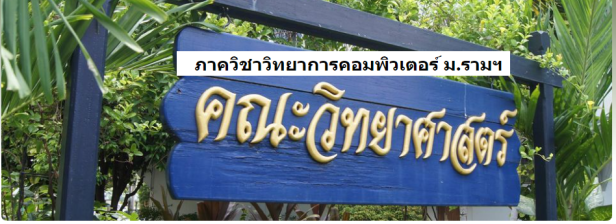

## Spatial Filtering

### Image mean filtering

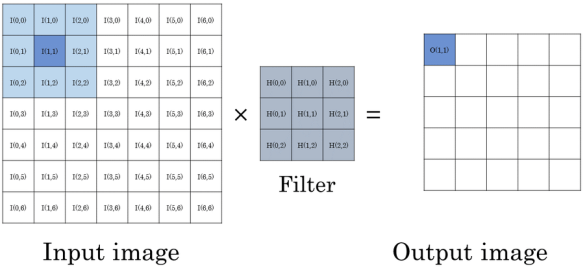

**Image mean filtering**, also known as **average filtering**, is a simple and commonly used image processing technique used to reduce noise in images. The basic idea behind mean filtering is to replace each pixel value in an image with the mean (average) value of its neighbors, including itself. This process smooths out rapid intensity changes and thus can effectively reduce noise.

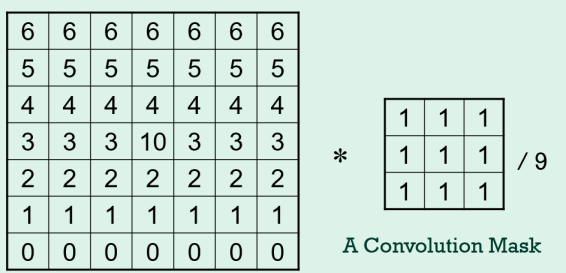

Here's a brief overview of how it works:

- **1. Neighborhood Definition:** First, a neighborhood around each pixel is defined. This is typically a square window centered on the pixel. The size of this window can vary, but common sizes are 3x3, 5x5, or 7x7 pixels.
- **2. Calculating the Mean:** For each pixel, calculate the mean of the pixel values in its neighborhood. This includes the pixel itself and its surrounding pixels within the window.
- **3. Replacing Pixel Values:** Replace the original pixel value with the calculated mean value. This is done for every pixel in the image.


### Import Module

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Show Image Module

In [2]:
def plt_show(img):
    plt.axis("off")
    plt.imshow(img, cmap='gray')
    plt.show()

In [3]:
def cv_show(img):
    cv2.imshow('Mean Filtered Image', img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    

#### Method 1 using cv library

In [7]:
def Blur(img, k):
    return cv2.blur(img, (k, k)).astype(np.uint8)
    
  

In [19]:
def filterImage(img, k):
    mask = np.ones([k,k], dtype = 'float16')/ 9
    #mask = np.array([[1,2,1],[2,4,2],[1,2,1]], dtype='float16')     
    #mask = mask/16
    return cv2.filter2D(img, -1, mask)    


### 1. Read Image

In [13]:
gray = cv2.imread('./images/lena_salt_512.png', 0)

In [13]:
blur_img = Blur(gray,7)
#blur_img = cv2.blur(gray, (3, 3)).astype(np.uint8)
imgs = cv2.hconcat([gray, blur_img])
cv_show(imgs)


In [23]:
def filterImage(img, k):
    #mask = np.ones([k,k], dtype = 'float16')/ (k**2)
    mask = np.array([[1,2,1],[2,4,2],[1,2,1]], dtype='float16')     
    mask = mask/16
    return cv2.filter2D(img, -1, mask).astype(np.uint8)



In [16]:
def filterCustom(img, k):
    mask = np.ones([k,k], dtype = 'float')/ (k**2)
    #mask = np.array([[1,2,1],[2,4,2],[1,2,1]], dtype='float16')     
    #mask = mask/16
    (m,n) = img.shape
    #out = np.zeros((m,n), dtype = 'float16')
    #out = np.zeros_like(img, dtype = 'float16')
    out = img.copy()
    bd = int(k/2)
    for i in range(bd,m-bd):
        for j in range(bd,n-bd):
            sub_f = img[i - bd : i + bd + 1, j - bd : j + bd + 1].astype(np.float16)
            out[i, j] = np.multiply(sub_f, mask).sum()    
    return out.astype(np.uint8)

In [17]:
blur_img =filterCustom(gray, 7)
imgs = cv2.hconcat([gray, blur_img])
cv_show(imgs)